In [5]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis


| Название столбца | Описание | Значения |
| :--- | :--- | :--- |
| **ID** | Идентификатор клиента | ID |
| **LIMIT_BAL** | Лимит кредита | NT доллары |
| **SEX** | Пол | 1=муж, 2=жен |
| **EDUCATION** | Образование | 1=маг, 2=унив, 3=школа, 4=др, 5-6=н/д |
| **MARRIAGE** | Семейное положение | 1=в браке, 2=холост, 3=др |
| **AGE** | Возраст | Лет |
| **PAY_0** | Статус выплат (Сентябрь) | -1=в срок, 1...8=мес. задержки, 9=9+ |
| **PAY_2** | Статус выплат (Август) | -1=в срок, 1...8=мес. задержки, 9=9+ |
| **PAY_3** | Статус выплат (Июль) | -1=в срок, 1...8=мес. задержки, 9=9+ |
| **PAY_4** | Статус выплат (Июнь) | -1=в срок, 1...8=мес. задержки, 9=9+ |
| **PAY_5** | Статус выплат (Май) | -1=в срок, 1...8=мес. задержки, 9=9+ |
| **PAY_6** | Статус выплат (Апрель) | -1=в срок, 1...8=мес. задержки, 9=9+ |
| **BILL_AMT1** | Сумма счета (Сентябрь) | NT доллары |
| **BILL_AMT2** | Сумма счета (Август) | NT доллары |
| **BILL_AMT3** | Сумма счета (Июль) | NT доллары |
| **BILL_AMT4** | Сумма счета (Июнь) | NT доллары |
| **BILL_AMT5** | Сумма счета (Май) | NT доллары |
| **BILL_AMT6** | Сумма счета (Апрель) | NT доллары |
| **PAY_AMT1** | Предыдущий платеж (Сентябрь) | NT доллары |
| **PAY_AMT2** | Предыдущий платеж (Август) | NT доллары |
| **PAY_AMT3** | Предыдущий платеж (Июль) | NT доллары |
| **PAY_AMT4** | Предыдущий платеж (Июнь) | NT доллары |
| **PAY_AMT5** | Предыдущий платеж (Май) | NT доллары |
| **PAY_AMT6** | Предыдущий платеж (Апрель) | NT доллары |
| **default.payment.next.month** | Дефолт в след. месяце | 1=да, 0=нет |


### 1) Разведовательный анализ. Базовый анализ 

In [6]:
tmp_train = pd.read_csv('UCI_Credit_Card.csv')

In [7]:
go_train = tmp_train.copy()

In [8]:
go_train.tail(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1
29999,30000,50000.0,1,2,1,46,0,0,0,0,...,36535.0,32428.0,15313.0,2078.0,1800.0,1430.0,1000.0,1000.0,1000.0,1


In [9]:
go_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [10]:
go_train.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Вывод: 
- [x] ID: удалить 
- [x] SEX:  оставляем 1, 2 так как будем строить классификация, а не регрессию 


### 2) Одномерный анализ (Univariate Analysis)

In [11]:
from feature_engine.outliers import Winsorizer

capper = Winsorizer(capping_method='iqr', tail='both', fold=1.5)

go_train_capped = capper.fit_transform(go_train.drop(columns='default.payment.next.month'))


go_train_capped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         30000 non-null  int64  
 1   LIMIT_BAL  30000 non-null  float64
 2   SEX        30000 non-null  int64  
 3   EDUCATION  30000 non-null  float64
 4   MARRIAGE   30000 non-null  int64  
 5   AGE        30000 non-null  float64
 6   PAY_0      30000 non-null  float64
 7   PAY_2      30000 non-null  float64
 8   PAY_3      30000 non-null  float64
 9   PAY_4      30000 non-null  float64
 10  PAY_5      30000 non-null  float64
 11  PAY_6      30000 non-null  float64
 12  BILL_AMT1  30000 non-null  float64
 13  BILL_AMT2  30000 non-null  float64
 14  BILL_AMT3  30000 non-null  float64
 15  BILL_AMT4  30000 non-null  float64
 16  BILL_AMT5  30000 non-null  float64
 17  BILL_AMT6  30000 non-null  float64
 18  PAY_AMT1   30000 non-null  float64
 19  PAY_AMT2   30000 non-null  float64
 20  PAY_AM

#### Визуальзация 

### 3) Многомерный анализ (Multivariate Analysis)
 - Корреляционная матрица (Heatmap): поиск сильно связанных признаков (мультиколлинеарность). Если два признака коррелируют на 0.99, один из них можно удалить
 - Scatter plots (диаграммы рассеяния): визуализация связи между двумя числовыми признаками

#### Матрица корреляции 

In [12]:
def ShowCorrCols(data):
    plt.figure(figsize=(25,25))

    corr_matrix = data.corr(numeric_only=True)
    sns.heatmap(corr_matrix, cmap='Blues', center=0, annot=True)
    plt.title('Correlogram', fontsize=22)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

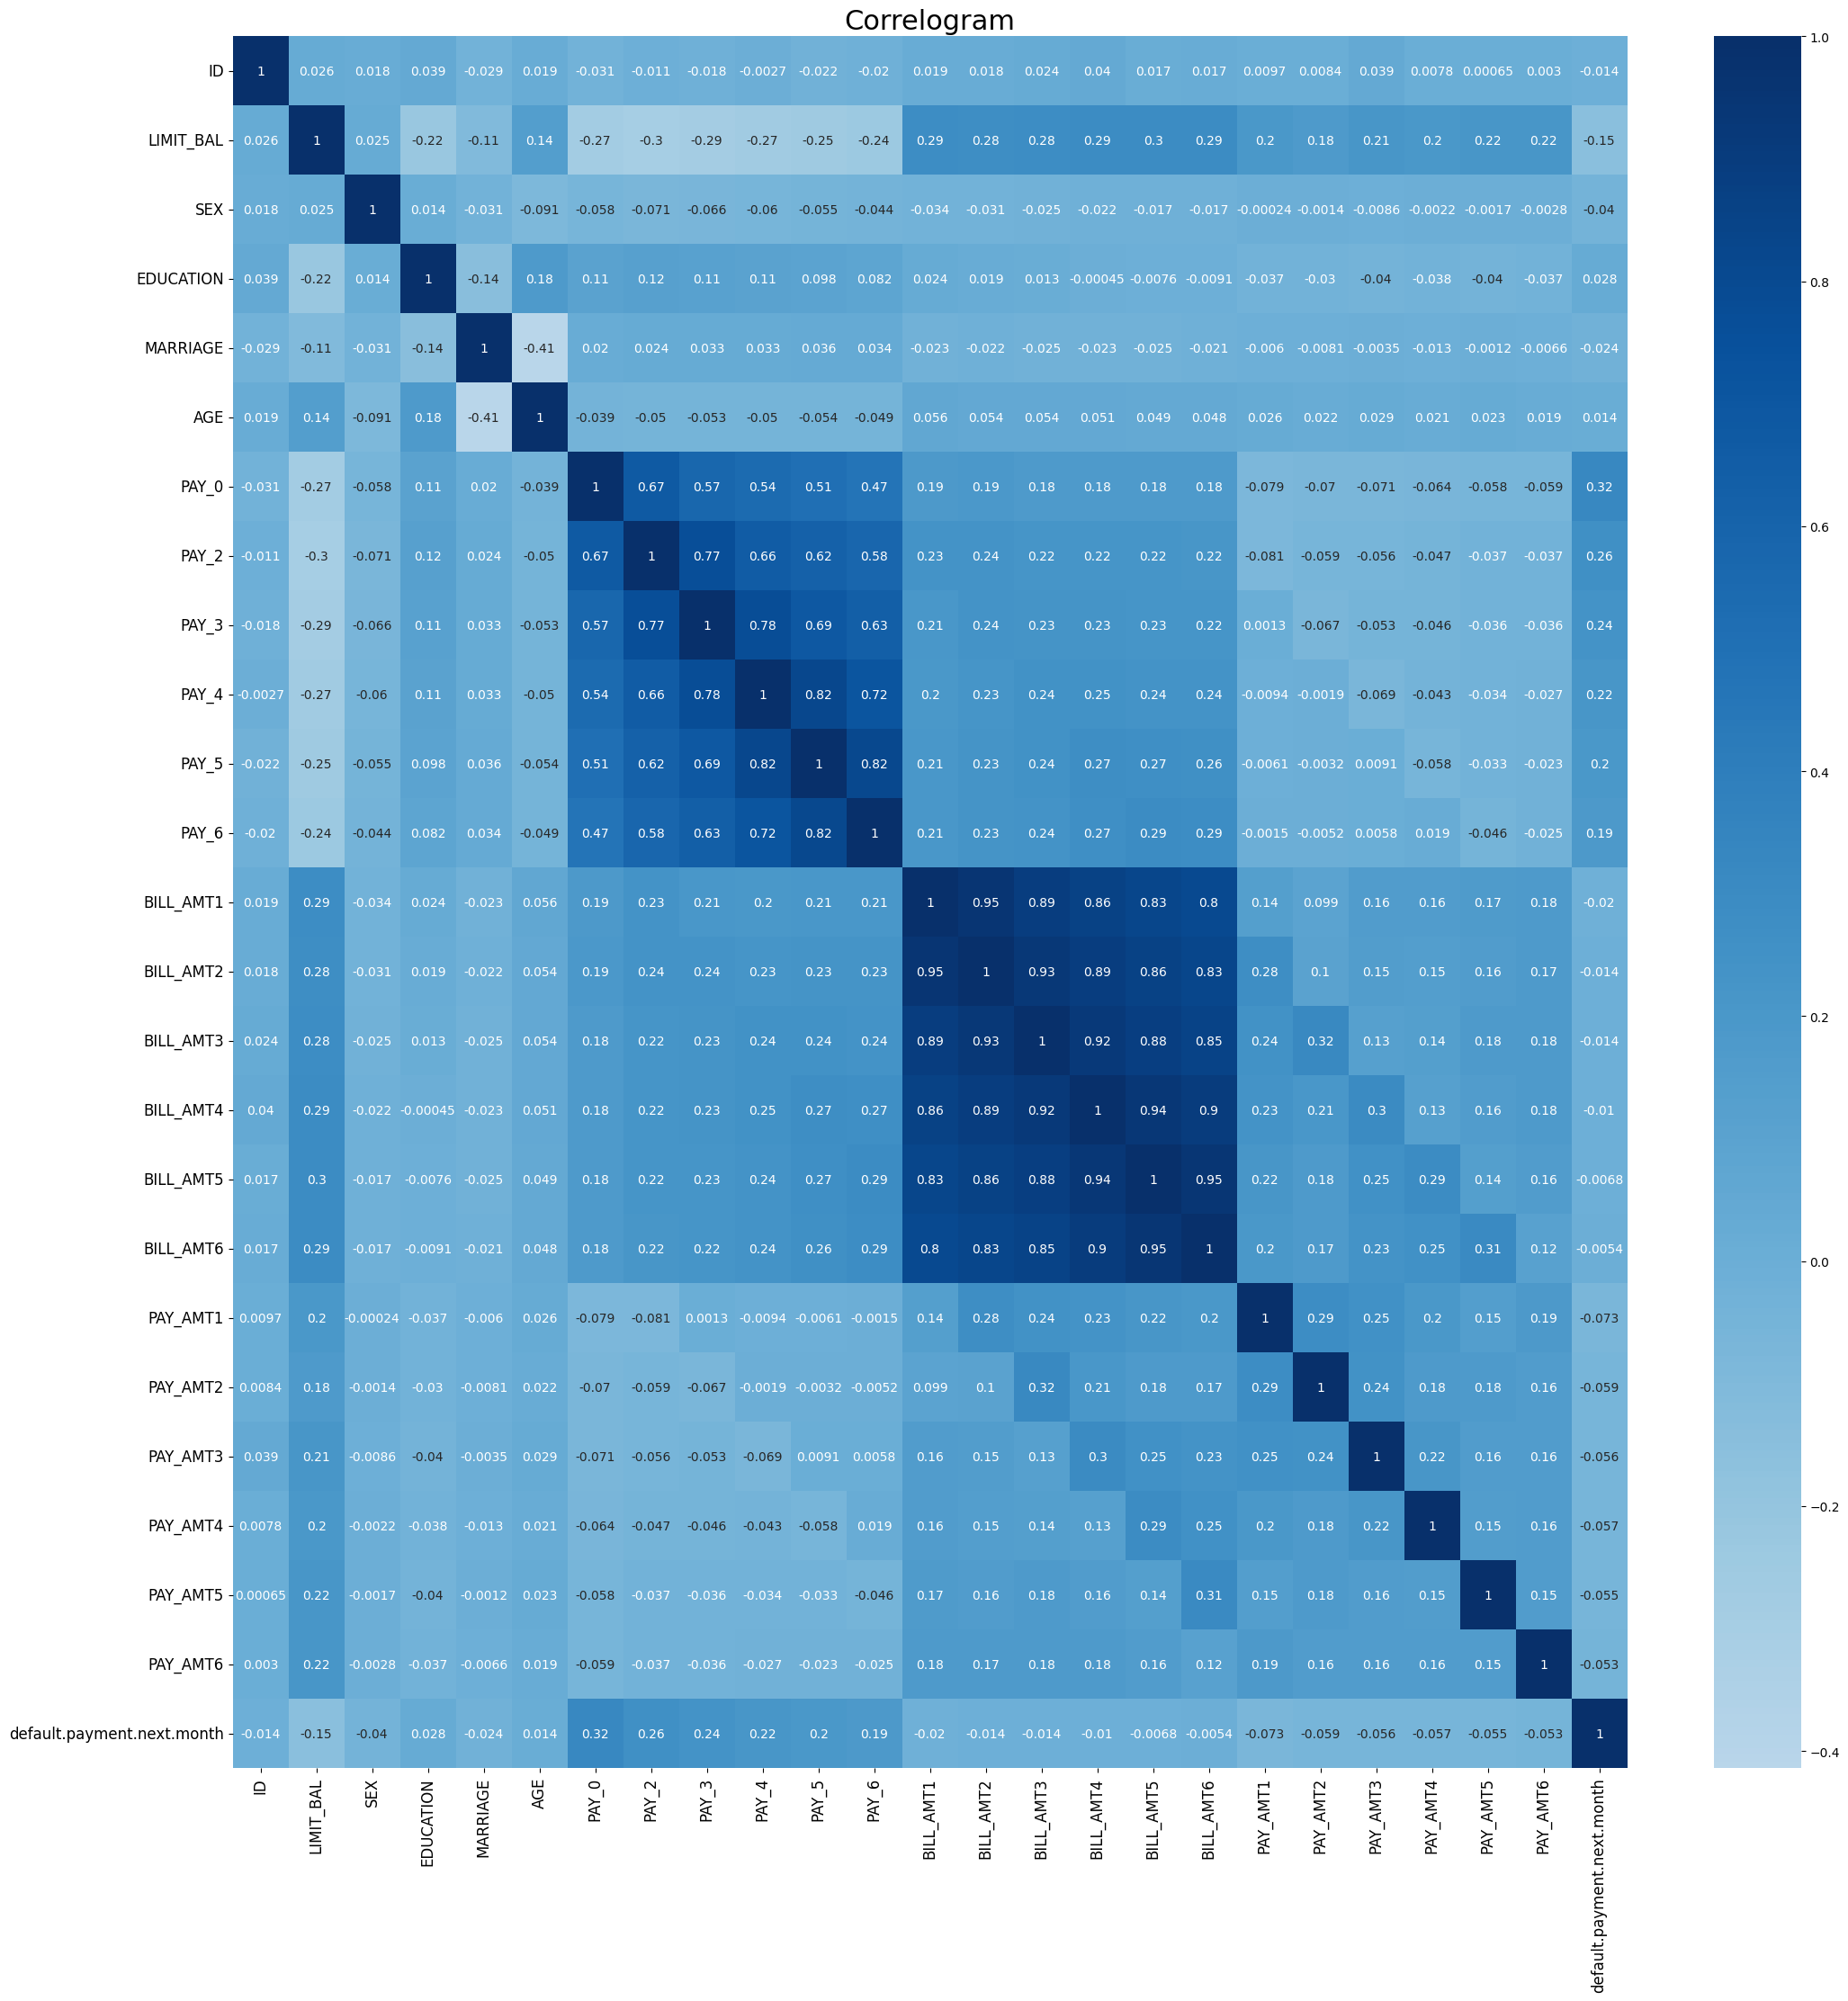

In [13]:
ShowCorrCols(go_train)

### 4) Анализ целевой переменной (Target Analysis)
 - проверка распределения (нормальное, смещенное, мультимодальное).
 - проверка баланса классов. Если один класс встречается в 95% случаев, модель будет склонна просто «угадывать» его 

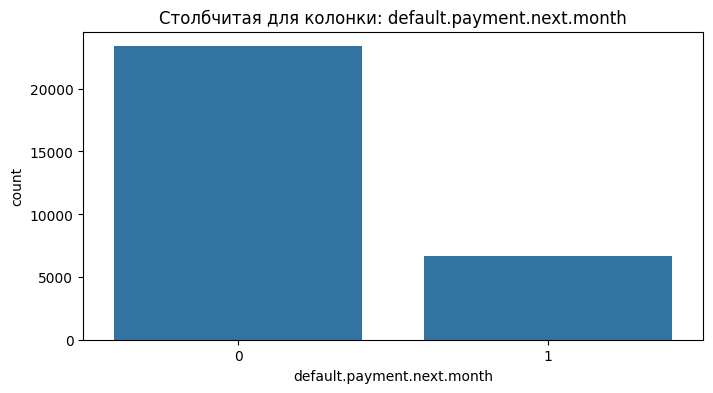

In [14]:
def ShowLogCountPlotAllCol(X):
    
    l_numeric_cols = X.columns

    for col in l_numeric_cols:
        plt.figure(figsize=(8, 4))
        sns.countplot(x=X[col])
        plt.title(f'Столбчитая для колонки: {col}')
        plt.show()

        
ShowLogCountPlotAllCol(go_train[['default.payment.next.month']])

### Выводы по исследованию

- перед обучением выполнить балансировку классов но лучше укажем параметр class_weight='balanced'

In [ ]:
def add_new_cols(df):
    df['utilization_1'] = df['BILL_AMT1'] / df['LIMIT_BAL']
    df['utilization_2'] = df['BILL_AMT2'] / df['LIMIT_BAL']
    df['utilization_3'] = df['BILL_AMT3'] / df['LIMIT_BAL']
    df['utilization_4'] = df['BILL_AMT4'] / df['LIMIT_BAL']
    df['utilization_5'] = df['BILL_AMT5'] / df['LIMIT_BAL']
    df['utilization_6'] = df['BILL_AMT6'] / df['LIMIT_BAL']

    #сумма платежа к прошлому счету 
    df['pay_to_bill_ratio_1'] = df['PAY_AMT1'] / (df['BILL_AMT2'] + 1)
    df['pay_to_bill_ratio_2'] = df['PAY_AMT2'] / (df['BILL_AMT3'] + 1)
    df['pay_to_bill_ratio_3'] = df['PAY_AMT3'] / (df['BILL_AMT4'] + 1)
    df['pay_to_bill_ratio_4'] = df['PAY_AMT4'] / (df['BILL_AMT5'] + 1)
    df['pay_to_bill_ratio_5'] = df['PAY_AMT5'] / (df['BILL_AMT6'] + 1)

    #прирост долга 
    df['bill_diff_1_2'] = df['BILL_AMT1'] - df['BILL_AMT2']
    df['bill_diff_2_3'] = df['BILL_AMT2'] - df['BILL_AMT3']
    df['bill_diff_3_4'] = df['BILL_AMT3'] - df['BILL_AMT4']
    df['bill_diff_4_5'] = df['BILL_AMT4'] - df['BILL_AMT5']
    df['bill_diff_5_6'] = df['BILL_AMT5'] - df['BILL_AMT6']

    # Список всех колонок со счетами
    bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

    # Средний счет и средний платеж
    df['avg_bill'] = df[bill_cols].mean(axis=1)
    df['avg_pay'] = df[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean(axis=1)

    pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

    # Считаем количество месяцев с просрочкой
    df['months_with_delay'] = (df[pay_status_cols] > 0).sum(axis=1)

    return df


go_train = add_new_cols(go_train)



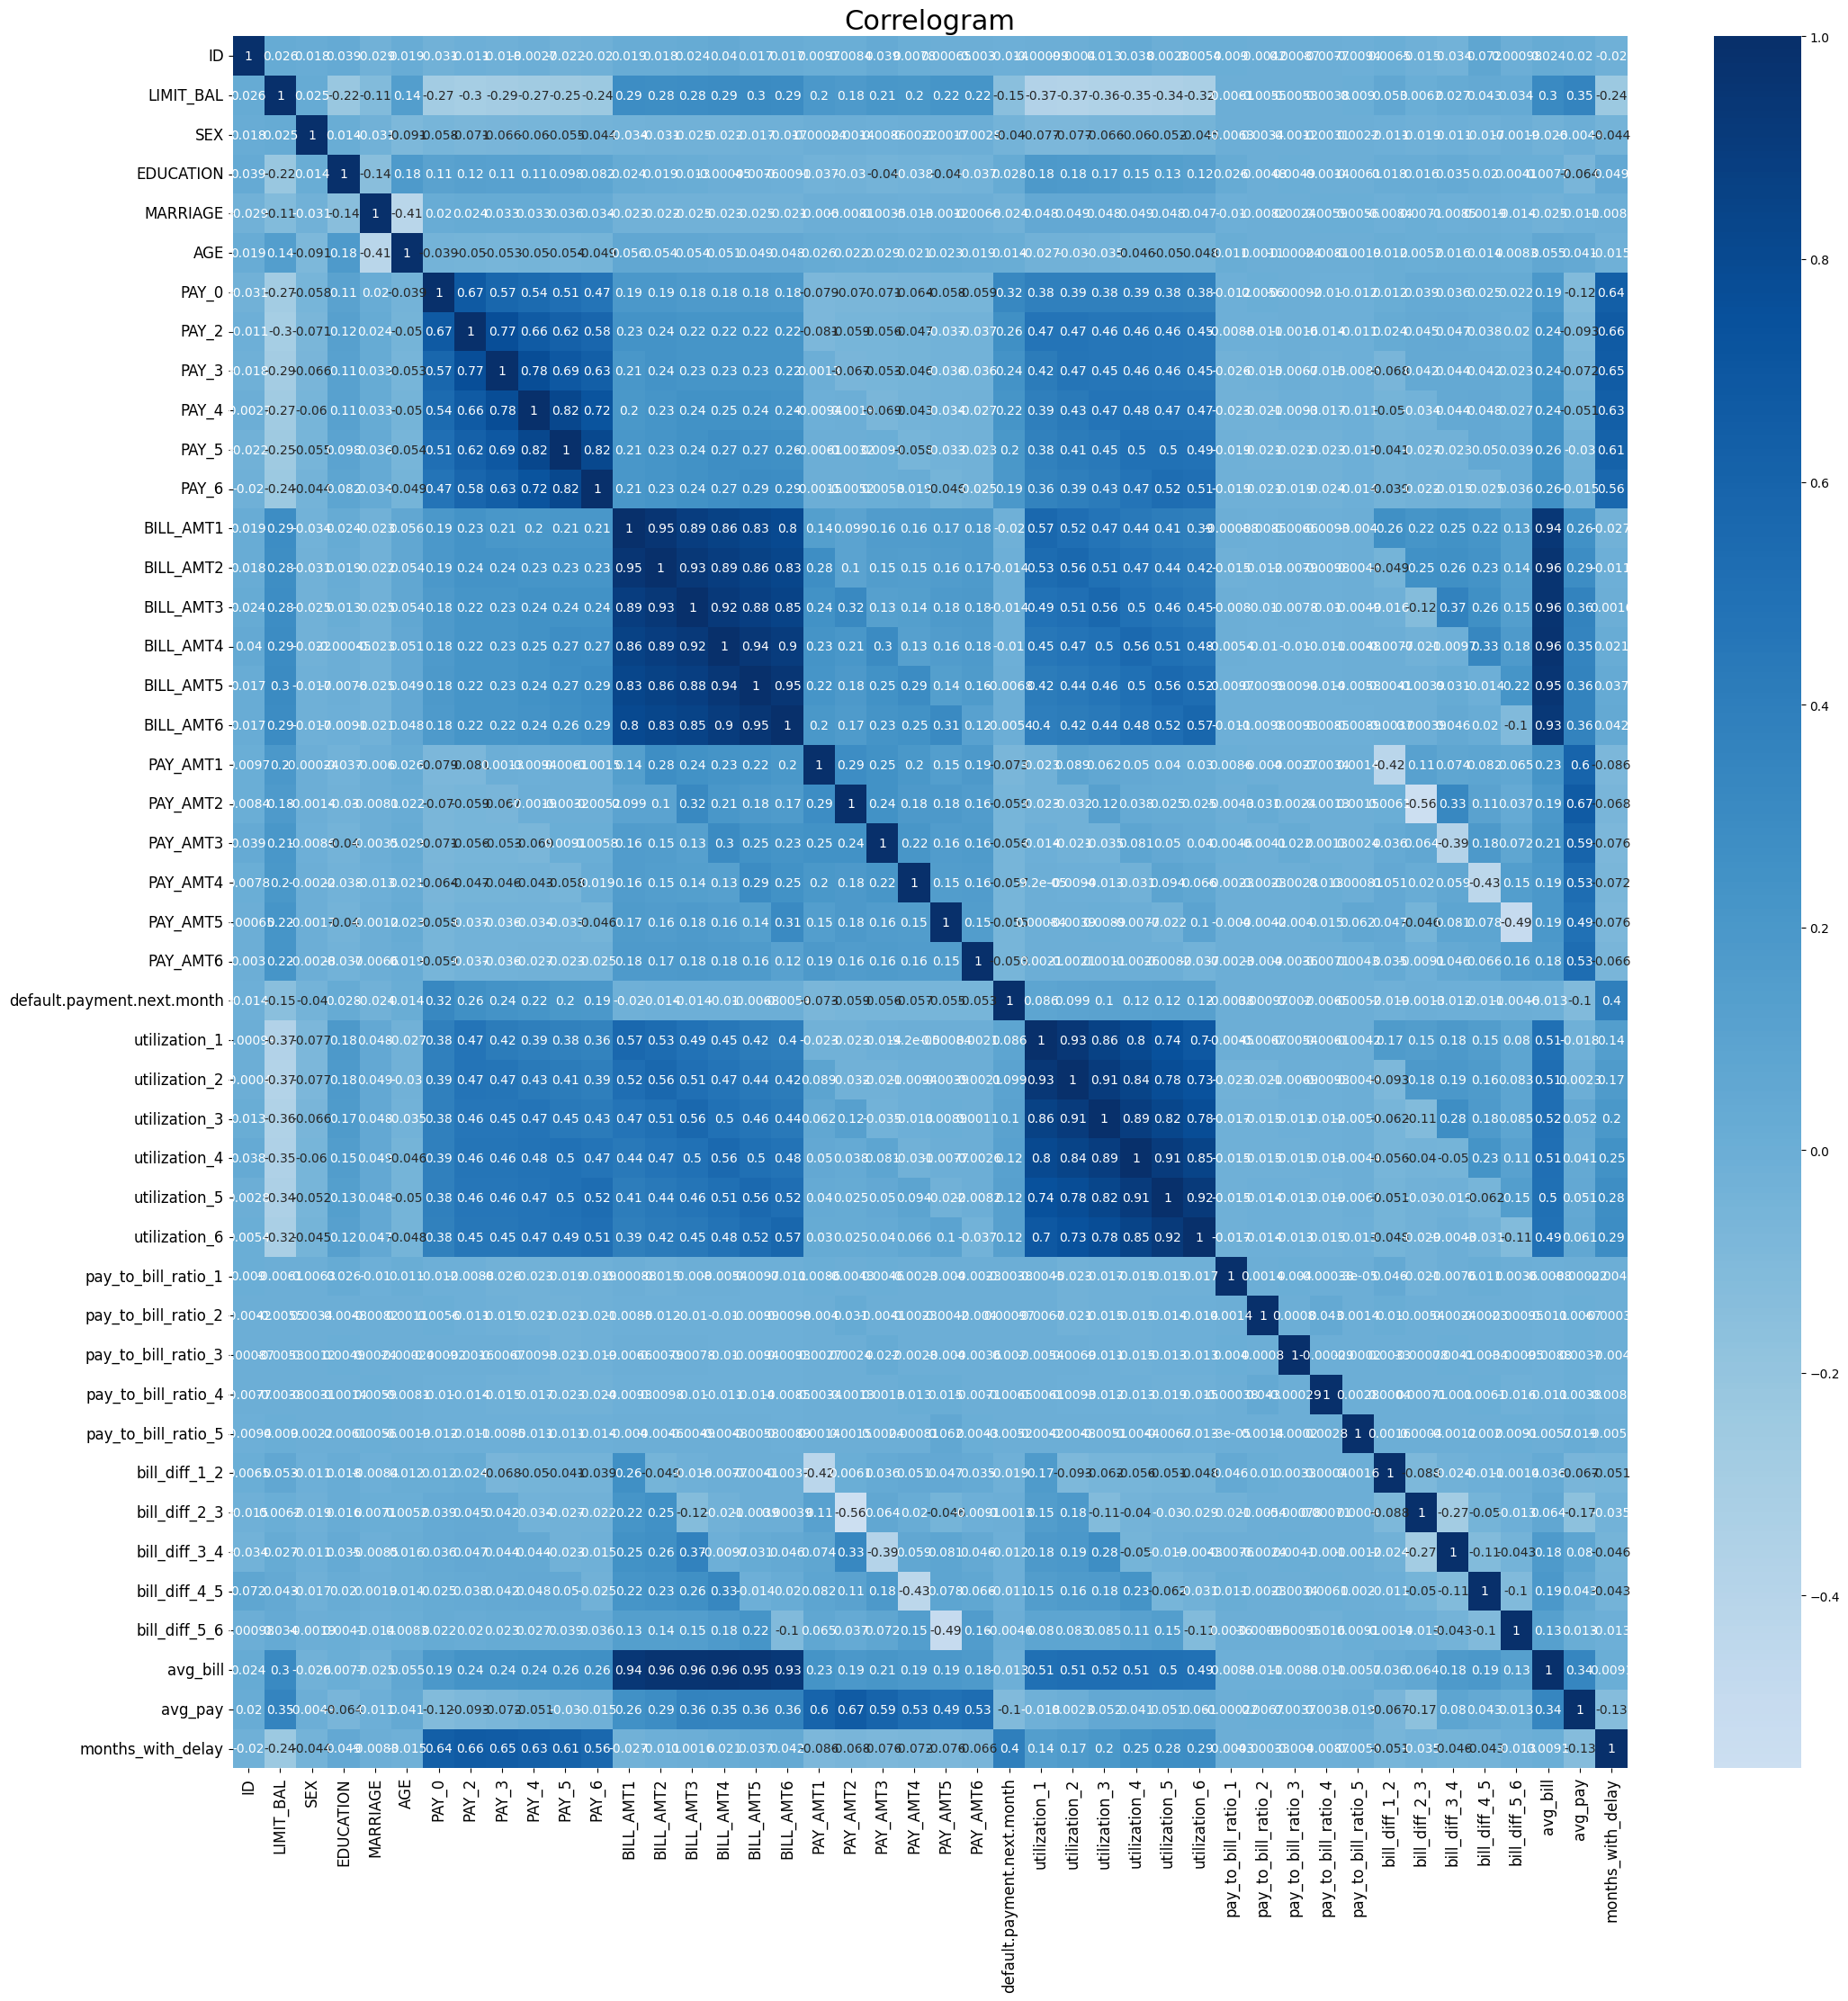

In [16]:
ShowCorrCols(go_train)